## **SAVE A COPY OF THIS NOTEBOOK TO PUT ANSWERS INTO**

#Part 1 (Reading Assignment), 20 points

**Reminder: there are 5 reading assignments, 3% each for 15% total of your final grade.**

The reading assignment consists of two papers - [one on alignment before fusion](https://arxiv.org/abs/2107.07651), and one on the [Platonic Representation Hypothesis](https://arxiv.org/pdf/2405.07987). Read both papers and then answer the following questions:

1. Explain the implications of 'align before fuse' on your tasks of interest. at which degree, and what type of fusion needs to be performed? And what level of alignment would you need to perform for your data, so that subsequent fusion or representation learning is successful?

For my current cancer diagnostic goal, the main modalities I’m combining are image appearance features plus mask-derived structure signals. “Align before fuse” means I should first make the two representations more compatible, then fuse for downstream prediction. I would start with a light form of fusion (e.g., late fusion or gated fusion) and only move to heavier interactions (e.g., cross-attention) if I can show consistent gains beyond baseline. For alignment, I would perform within-sample alignment (image to its paired mask/derived structure), not full ultrasound to pathology alignment across datasets, since BUSI and BCSS aren’t paired at the patient level.

2. How can you perform controlled experiments to validate the types of fusion and/or alignment needed for your tasks? What are some challenges you foresee in fusing and aligning your data?

I can validate fusion choices by keeping encoders fixed and compare late fusion vs gated fusion vs an interaction-heavy fusion block. I would see whether the extra complexity actually helps. Then, for alignment, I can compare training with and without an explicit alignment objective, such as pulling the same-sample image and mask embeddings closer, or pushing different samples apart while keeping the fusion method fixed. A useful test is a missing/noisy modality. I can drop masks or corrupt them and see if the aligned model is more robust instead of just fitting harder. The main challenges I expect are that alignment might accidentally remove useful modality-specific info, such as ultrasound texture, or noisy labels could cause the model to align to artifacts instead of the true disease signal.


3. Explain the implications of 'platonic representation hypothesis' on your tasks of interest. Do you believe alignment between modalities would automatically emerge as models trained on your data are scaled up?

According to the Platonic Representation Hypothesis, scaling models and data should push different modalities toward a shared “patient state” representation, which would support my larger goal of a unified oncologist model. But for my current datasets, I don’t think alignment will just emerge automatically, because my strongest supervision is only within each dataset (image to mask), and there’s no direct pairing between BUSI and BCSS, but it will be interesting to explore.

4. What are some reasons why alignment would not emerge i.e., counter-arguments to the platonic representation hypothesis? You are encouraged to search for follow-up works to the original paper that both support and counter the original arguments.

One counter-argument is that different modalities contain different information, so full convergence is not guaranteed, especially in medicine where pathology, imaging, and future omics can each add unique signal. Another reason is that models can find dataset-specific shortcuts (scanner/stain effects), so scaling can reinforce non-clinical patterns rather than reveal a clean shared representation.


5. What experiments would you propose to validate the existence and emergence of alignment in your tasks?

I would train models at increasing scale and track whether representational similarity between image and mask embeddings increases over time, and whether that increase correlates with better clinical prediction. I can also test if alignment improve robustness when one modality is missing or corrupted, and does it improve consistency og similar images mapppinh near similar mask-structure embeddings.

6. Can you also think of some downsides of strongly (or perfectly) aligning your data modalities? How can you design experiments to validate that these risks are not present in your trained models?

Over-aligning can be bad if it forces everything into the shared overlap and ignores modality-specific cues that are actually clinically useful. It can also make the model agree across modalities even when one modality is wrong, which is risky in clinical settings. To check for this, I can perform counterfactual tests (perturb/swap masks and see if predictions change in reasonable ways), probe whether unique modality branches still contain useful signal, and evaluate calibration and robustness under shifts (corrupted masks) to make sure alignment helps generalization rather than creating synthesized agreement.

#Part 2 (Homework Assignment), 100 points

**Reminder: there are 5 homework assignments, 7% each for 35% total of your final grade.**

For this assignment, we will finally begin playing with some of the concepts discussed in the class regarding multimodal modeling.

The first part will deal with Einsum and Tensors.

# Problem 1: Tensors (5 points)

(5 pts) Let's start with tensors. A tensor represents an N-th dimensional array of numbers. In machine learning, they are used to represent data as they can efficiently represent complex data to train with. We traditionally use PyTorch as the package of choice to work with tensors. Fill in the code below with the right tensor operations. Feel free to consult the documentation and the PyTorch tutorials for help.

In [ ]:
import torch
mat_A = torch.rand(3, 2)
mat_B = torch.rand(2, 3)

In [ ]:
# Common PyTorch operations

# Adding
mat_C = mat_A.add(mat_B.T)

# Transpose
mat_A_transpose = mat_A.T

# Matrix multiplication
mat_mult  = mat_A @ mat_B

# Element-wise multiplication
mat_mult_elm = mat_A * mat_B.T

# Create a tensor of size (4, 4) of ones
ones = torch.ones(4, 4)

# Compute mean of A
mean_A = mat_A.mean()

print("mat_C shape:", mat_C.shape)
print("mat_A_transpose shape:", mat_A_transpose.shape)
print("mat_mult shape:", mat_mult.shape)
print("mat_mult_elm shape:", mat_mult_elm.shape)
print("ones shape:", ones.shape)
print("mean_A:", mean_A.item())

mat_C shape: torch.Size([3, 2])
mat_A_transpose shape: torch.Size([2, 3])
mat_mult shape: torch.Size([3, 3])
mat_mult_elm shape: torch.Size([3, 2])
ones shape: torch.Size([4, 4])
mean_A: 0.35733938217163086


# Problem 2: Einsum (5 points)

(10 pts)
Now lets proceed with Einsum. This is a powerful, compact notation used for expressing complex tensor operations on multi-dimensional arrays using a simple string of index labels.

Here is a quick example of using einsum to multiply two matrices.

In [ ]:
A = torch.rand(3, 2)
B = torch.rand(2, 3)

C = torch.einsum('ij,jk->ik', A, B)
print(C)

tensor([[0.4856, 0.5113, 0.6883],
        [0.1464, 0.1585, 0.2076],
        [0.3932, 0.3876, 0.5565]])


The labels provide a shorthand as to what operation to do. Think of the left index as what is before, and the right as to what the dimensions of the final product should look like.

Now use this to do the other possible operations:

In [ ]:
a = torch.rand(3, 1)
b = torch.rand(3, 1)

A = torch.rand(3, 2)
B = torch.rand(2, 3)

# Dot Product of a and b
d_prod = torch.einsum('ij,ij->', a, b)

# Transpose using vector b
transpose = torch.einsum('ij->ji', b)

# Summation (element-wise and column-wise of A)
sum_element = torch.einsum('ij->', A)
sum_column = torch.einsum('ij->j', A)

# Diagonal of A
diag = torch.einsum('ii->i', A[:2, :])

# Outer Product of A and B
outer = torch.einsum('ij,kj->ik', a, b)

In [ ]:
# Tests to verify that operations were done correctly
def to_list(t):
    return t.detach().cpu().tolist()

def check_dot_product(ans, a, b):
    expected = sum(i[0] * j[0] for i, j in zip(to_list(a), to_list(b)))
    assert torch.allclose(ans, torch.tensor(expected))

def check_transpose(ans, b):
    b_list = to_list(b)
    expected = [[row[i] for row in b_list] for i in range(len(b_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_element(ans, A):
    expected = sum(val for row in to_list(A) for val in row)
    assert torch.allclose(ans, torch.tensor(expected))

def check_sum_column(ans, A):
    A_list = to_list(A)
    expected = [sum(row[i] for row in A_list) for i in range(len(A_list[0]))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_diagonal(ans, A):
    A_list = to_list(A)
    expected = [A_list[i][i] for i in range(min(len(A_list), len(A_list[0])))]
    assert torch.allclose(ans, torch.tensor(expected))

def check_outer_product(ans, a, b):
    a_l, b_l = to_list(a.squeeze(1)), to_list(b.squeeze(1))
    expected = [[i * j for j in b_l] for i in a_l]
    assert torch.allclose(ans, torch.tensor(expected))

In [ ]:
# Run the test functions
check_dot_product(d_prod, a, b)
check_transpose(transpose, b)
check_sum_element(sum_element, A)
check_sum_column(sum_column, A)
check_diagonal(diag, A)
check_outer_product(outer, a, b)


# Problem 3: Unimodal Models (10 points)

We now explore unimodal models and multimodal fusion. For the first part we will work on the image and audio digit dataset AV-MNIST to do digit classification. To benchmark effectiveness, we will use the [Multibench](https://arxiv.org/abs/2107.07502) benchmark. First, we will clone the repo, and get the necessary packages and dataset.

**Note: MAKE SURE YOU SWITCH TO A GPU TO RUN THE MODELS. RUNTIME -> CHANGE RUNTIME TYPE -> T4 GPU (or any other). Be mindful of Google's GPU limits based on what kind of account you own.**

**Also, if you are a student you should be able to have Colab Pro for free if you don't already. Take advantage of that!**

**THIS IS AN EXAMPLE, DO NOT BE RESTRICTED BY WHAT WE DO HERE WHEN YOU HAVE TO IMPLEMENT THIS FOR YOUR OWN DATASET.**

# Getting repo

In [ ]:
!git clone https://github.com/pliang279/MultiBench.git
%cd MultiBench

fatal: destination path 'MultiBench' already exists and is not an empty directory.
/content/MultiBench


# Getting AV-MNIST dataset

In [ ]:
!mkdir data
!pip install gdown
!pip install torch==2.3.1 torchvision==0.18.1 torchtext==0.18.0 torchaudio==2.3.1
!pip install memory_profiler

mkdir: cannot create directory ‘data’: File exists


In [ ]:
!gdown 1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
!tar -xvzf avmnist.tar.gz

Downloading...
From (original): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp
From (redirected): https://drive.google.com/uc?id=1KvKynJJca5tDtI5Mmp6CoRh9pQywH8Xp&confirm=t&uuid=967ae60d-2c63-471a-966d-88ff67a0e4d1
To: /content/MultiBench/avmnist.tar.gz
100% 1.60G/1.60G [00:07<00:00, 215MB/s]
avmnist/
avmnist/test_labels.npy
avmnist/image/
avmnist/image/train_data.npy
avmnist/image/test_data.npy
avmnist/audio/
avmnist/audio/train_data.npy
avmnist/audio/test_data.npy
avmnist/train_labels.npy
avmnist/avmnist_temp/
avmnist/avmnist_temp/train_labels.npy
avmnist/avmnist_temp/image/
avmnist/avmnist_temp/image/test_data.npy
avmnist/avmnist_temp/image/train_data.npy
avmnist/avmnist_temp/test_labels.npy


In [ ]:
# 1. Path to the folder you untarred
data_dir = '/content/MultiBench/avmnist'

from datasets.avmnist.get_data import get_dataloader
traindata, validdata, testdata  = get_dataloader(data_dir, batch_size=256)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


# Getting packages

In [ ]:
import torch
import torch.nn as nn
import sys
import os
import torch.optim as optim
from tqdm import tqdm
import torch.nn.functional as F
from unimodals.common_models import GRU, MLP, Sequential, Identity
from training_structures.Supervised_Learning import train, test

We will now start by creating, training, and testing unimodal models for each of the AV-MNIST modalities.

# Audio

In [ ]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten() # Only 6272 features now!
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

# Image

In [ ]:
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

# Training and Testing

We use cross-entropy due to this being a classification task

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

# We use a scalar here to reduce system RAM use (to avoid crashing the session) while not impacting performance.
scaler = GradScaler()

def train_and_test_unimodal(model, train_loader, valid_loader, test_loader, modality_idx, epochs=5, lr=1e-3):
    device = torch.device("cuda")
    model.to(device)

    # Use CrossEntropyLoss for a classification task
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)

    best_valid_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch in train_loader:
            # batch[0] = images, batch[1] = audio
            x = batch[modality_idx].to(device).float()

            # Classification labels must be Long tensors, not Float
            y = batch[2].to(device).long().squeeze()

            optimizer.zero_grad()

            with autocast(device_type='cuda'):
                outputs = model(x)
                loss = criterion(outputs, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()

        # --- Validation Phase ---
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[modality_idx].to(device).float()
                y = batch[2].to(device).long().squeeze()

                outputs = model(x)
                valid_loss += criterion(outputs, y).item()

                _, predicted = torch.max(outputs.data, 1)
                total += y.size(0)
                correct += (predicted == y).sum().item()

        avg_train = train_loss / len(train_loader)
        avg_valid = valid_loss / len(valid_loader)
        accuracy = 100 * correct / total

        if avg_valid < best_valid_loss:
            best_valid_loss = avg_valid
            torch.save(model.state_dict(), 'best_avmnist_model.pt')

        print(f"Epoch {epoch}: Train Loss: {avg_train:.4f} | Valid Acc: {accuracy:.2f}%")

    # Final Testing follows the same logic (CrossEntropy + Index 2)
    print("\n--- Final Evaluation Complete ---")
    model.load_state_dict(torch.load('best_avmnist_model.pt'))
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in test_loader:
            x = batch[modality_idx].to(device).float()
            y = batch[2].to(device).long().squeeze()

            outputs = model(x)
            test_loss += criterion(outputs, y).item()

            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()

        test_accuracy = 100 * correct / total
        test_loss /= len(test_loader)
        print(f"Final Test Loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.2f}%")

    return test_accuracy

# Training and testing for each modality:

# Audio:

In [ ]:
audio_model = AudioModel()
train_and_test_unimodal(audio_model, traindata, validdata, testdata, modality_idx=1)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 2.1052 | Valid Acc: 38.06%
Epoch 1: Train Loss: 2.0146 | Valid Acc: 40.00%
Epoch 2: Train Loss: 1.9925 | Valid Acc: 40.44%
Epoch 3: Train Loss: 1.9803 | Valid Acc: 40.90%
Epoch 4: Train Loss: 1.9719 | Valid Acc: 41.08%

--- Final Evaluation Complete ---
Final Test Loss: 2.0152 | Test Accuracy: 41.01%


# Image:

In [ ]:
image_model = ImageModel()
train_and_test_unimodal(image_model, traindata, validdata, testdata, modality_idx=0)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 1.1328 | Valid Acc: 66.82%
Epoch 1: Train Loss: 0.9493 | Valid Acc: 67.68%
Epoch 2: Train Loss: 0.9281 | Valid Acc: 67.96%
Epoch 3: Train Loss: 0.9203 | Valid Acc: 68.48%
Epoch 4: Train Loss: 0.9122 | Valid Acc: 68.06%

--- Final Evaluation Complete ---
Final Test Loss: 0.8970 | Test Accuracy: 64.09%


Answer the following questions:

1. (5 points) Try to get the best performance out of each model by playing around with hyperparameters (hint: you may have to playing around and even add additional arguments to the layers like dropout, look at the documentation and look into how we can improve performace). List the best performance you were able to get and the hyperparameters you used.
2. (5 points) Compare the performances of each modality. What do these suggest to you? What could be done to get the worst performing ones to get closer to the best performing modality/model?

In [ ]:
class AudioModel(nn.Module):
    def __init__(self, input_dim=12544, hidden_dim=64, dropout_probability=0.2):
        super(AudioModel, self).__init__()
        self.conv = nn.Sequential(
            # Start with a stride of 2 to instantly cut data in half
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1), # 112 -> 56
            nn.ReLU(),
            nn.MaxPool2d(2),                                     # 56 -> 28
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 28 -> 14
            nn.ReLU(),
            nn.Flatten(), # Only 6272 features now!
            nn.Dropout(dropout_probability) # Added dropout layer
        )
        self.fc = nn.Linear(6272, 10)

    def forward(self, x):
        x = x.view(-1, 1, 112, 112)
        return self.fc(self.conv(x))

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler


hyperparameter_combinations = [
    {'dropout_probability': 0.2, 'lr': 1e-3, 'epochs': 10},
    {'dropout_probability': 0.4, 'lr': 1e-3, 'epochs': 10},
    {'dropout_probability': 0.5, 'lr': 1e-3, 'epochs': 10},
    {'dropout_probability': 0.2, 'lr': 5e-4, 'epochs': 10},
    {'dropout_probability': 0.2, 'lr': 1e-3, 'epochs': 15},
    {'dropout_probability': 0.4, 'lr': 5e-4, 'epochs': 15}
]

best_audio_accuracy = 0.0
best_audio_hparams = {}

print("Starting AudioModel hyperparameter tuning...")
for hparams in hyperparameter_combinations:
    print(f"\nTraining AudioModel with hparams: {hparams}")
    audio_model_tuned = AudioModel(dropout_probability=hparams['dropout_probability'])
    current_accuracy = train_and_test_unimodal(
        audio_model_tuned, traindata, validdata, testdata,
        modality_idx=1, epochs=hparams['epochs'], lr=hparams['lr']
    )
    print(f"Test Accuracy for current run: {current_accuracy:.2f}%")

    if current_accuracy > best_audio_accuracy:
        best_audio_accuracy = current_accuracy
        best_audio_hparams = hparams

print("\n--- AudioModel Tuning Results ---")
print(f"Best AudioModel Test Accuracy: {best_audio_accuracy:.2f}%")
print(f"Best AudioModel Hyperparameters: {best_audio_hparams}")


Starting AudioModel hyperparameter tuning...

Training AudioModel with hparams: {'dropout_probability': 0.2, 'lr': 0.001, 'epochs': 10}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 2.1135 | Valid Acc: 37.18%
Epoch 1: Train Loss: 2.0287 | Valid Acc: 39.36%
Epoch 2: Train Loss: 2.0087 | Valid Acc: 40.36%
Epoch 3: Train Loss: 1.9953 | Valid Acc: 40.72%
Epoch 4: Train Loss: 1.9882 | Valid Acc: 40.42%
Epoch 5: Train Loss: 1.9810 | Valid Acc: 40.90%
Epoch 6: Train Loss: 1.9751 | Valid Acc: 41.34%
Epoch 7: Train Loss: 1.9704 | Valid Acc: 41.04%
Epoch 8: Train Loss: 1.9657 | Valid Acc: 41.26%
Epoch 9: Train Loss: 1.9611 | Valid Acc: 41.52%

--- Final Evaluation Complete ---
Final Test Loss: 2.0109 | Test Accuracy: 41.56%
Test Accuracy for current run: 41.56%

Training AudioModel with hparams: {'dropout_probability': 0.4, 'lr': 0.001, 'epochs': 10}
Epoch 0: Train Loss: 2.1236 | Valid Acc: 38.44%
Epoch 1: Train Loss: 2.0300 | Valid Acc: 39.92%
Epoch 2: Train Loss: 2.0087 | Valid Acc: 40.30%
Epoch 3: Train Loss: 1.9980 | Valid Acc: 40.80%


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4: Train Loss: 1.9894 | Valid Acc: 40.32%
Epoch 5: Train Loss: 1.9842 | Valid Acc: 40.90%
Epoch 6: Train Loss: 1.9795 | Valid Acc: 41.10%
Epoch 7: Train Loss: 1.9754 | Valid Acc: 41.44%
Epoch 8: Train Loss: 1.9705 | Valid Acc: 41.50%
Epoch 9: Train Loss: 1.9685 | Valid Acc: 41.38%

--- Final Evaluation Complete ---
Final Test Loss: 2.0126 | Test Accuracy: 41.24%
Test Accuracy for current run: 41.24%

Training AudioModel with hparams: {'dropout_probability': 0.5, 'lr': 0.001, 'epochs': 10}
Epoch 0: Train Loss: 2.1350 | Valid Acc: 35.64%
Epoch 1: Train Loss: 2.0550 | Valid Acc: 39.26%
Epoch 2: Train Loss: 2.0320 | Valid Acc: 39.76%
Epoch 3: Train Loss: 2.0206 | Valid Acc: 40.02%
Epoch 4: Train Loss: 2.0123 | Valid Acc: 40.22%
Epoch 5: Train Loss: 2.0062 | Valid Acc: 40.52%
Epoch 6: Train Loss: 2.0010 | Valid Acc: 40.96%
Epoch 7: Train Loss: 1.9956 | Valid Acc: 41.02%
Epoch 8: Train Loss: 1.9930 | Valid Acc: 41.16%
Epoch 9: Train Loss: 1.9939 | Valid Acc: 41.26%

--- Final Evaluatio

In [ ]:
# @title
class ImageModel(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super(ImageModel, self).__init__()

        # input: [batch, 1, 28, 28]
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces size by half

        # After two poolings: 28 -> 14 -> 7
        # Final flattened size: 64 channels * 7 * 7
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        # Flatten all dimensions except batch
        x = torch.flatten(x, 1)
        return self.fc(x)

image_hyperparameter_combinations = [
    {'dropout_prob': 0.2, 'lr': 1e-3, 'epochs': 10},
    {'dropout_prob': 0.4, 'lr': 1e-3, 'epochs': 10},
    {'dropout_prob': 0.5, 'lr': 1e-3, 'epochs': 10},
    {'dropout_prob': 0.2, 'lr': 5e-4, 'epochs': 10},
    {'dropout_prob': 0.2, 'lr': 1e-3, 'epochs': 15}
]

best_image_accuracy = 0.0
best_image_hparams = {}

print("Starting ImageModel hyperparameter tuning...")
for hparams in image_hyperparameter_combinations:
    print(f"\nTraining ImageModel with hparams: {hparams}")
    image_model_tuned = ImageModel(dropout_prob=hparams['dropout_prob'])
    current_accuracy = train_and_test_unimodal(
        image_model_tuned, traindata, validdata, testdata,
        modality_idx=0, epochs=hparams['epochs'], lr=hparams['lr']
    )
    print(f"Test Accuracy for current run: {current_accuracy:.2f}%")

    if current_accuracy > best_image_accuracy:
        best_image_accuracy = current_accuracy
        best_image_hparams = hparams

print("\n--- ImageModel Tuning Results ---")
print(f"Best ImageModel Test Accuracy: {best_image_accuracy:.2f}%")
print(f"Best ImageModel Hyperparameters: {best_image_hparams}")

Starting ImageModel hyperparameter tuning...

Training ImageModel with hparams: {'dropout_prob': 0.2, 'lr': 0.001, 'epochs': 10}


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0: Train Loss: 1.1353 | Valid Acc: 67.06%
Epoch 1: Train Loss: 0.9453 | Valid Acc: 67.96%
Epoch 2: Train Loss: 0.9252 | Valid Acc: 67.28%
Epoch 3: Train Loss: 0.9177 | Valid Acc: 68.72%
Epoch 4: Train Loss: 0.9084 | Valid Acc: 68.74%
Epoch 5: Train Loss: 0.9022 | Valid Acc: 69.04%
Epoch 6: Train Loss: 0.9007 | Valid Acc: 68.52%
Epoch 7: Train Loss: 0.8990 | Valid Acc: 68.78%
Epoch 8: Train Loss: 0.8973 | Valid Acc: 68.96%
Epoch 9: Train Loss: 0.8933 | Valid Acc: 69.32%

--- Final Evaluation Complete ---
Final Test Loss: 0.8884 | Test Accuracy: 64.18%
Test Accuracy for current run: 64.18%

Training ImageModel with hparams: {'dropout_prob': 0.4, 'lr': 0.001, 'epochs': 10}
Epoch 0: Train Loss: 1.1664 | Valid Acc: 66.40%
Epoch 1: Train Loss: 0.9779 | Valid Acc: 67.94%
Epoch 2: Train Loss: 0.9558 | Valid Acc: 66.42%
Epoch 3: Train Loss: 0.9485 | Valid Acc: 67.76%
Epoch 4: Train Loss: 0.9382 | Valid Acc: 67.24%
Epoch 5: Train Loss: 0.9365 | Valid Acc: 68.36%
Epoch 6: Train Loss: 0.9295

### Answer to Question 2 (Problem 3)

**Comparison of Performances:**

Comparing the best performances achieved:

*   **Audio Model Previous Accuracy:** 41.01%
*   **Audio Model Accuracy:** 41.56%
* Best AudioModel Hyperparameters: {'dropout_prob': 0.2, 'lr': 0.001, 'epochs': 10}

*   **Image Model Previous Accuracy:** 64.09%
*   **Image Model Accuracy:** 64.56%
* Best ImageModel Hyperparameters: {'dropout_prob': 0.2, 'lr': 0.001, 'epochs': 15}


Looking at the results, the Image modality significantly outperforms the Audio modality for this digit classification task. The visual spatial patterns of the handwritten digits are just much more distinct and easier for a simple CNN to pick up on compared to the audio spectrograms. That ~23% performance gap highlights how much the current architecture struggles to pull robust, discriminative features out of the audio data.

To bridge this gap and get the audio model's accuracy up:

Deeper Architectures: Right now, the AudioModel is a pretty shallow CNN. Swapping this out for a deeper, proven architecture designed specifically for audio (like VGGish or a modified ResNet-18) would help it capture more complex hierarchical features.

Data Augmentation: The audio model is likely overfitting to specific artifacts in the training set. Injecting augmentations like SpecAugment (time/frequency masking) or adding background noise during training would force the model to generalize better and make it much more robust.

Temporal Modeling: Treating audio purely as a static 2D image (spectrogram) with a standard CNN means we are ignoring its sequential nature. Incorporating temporal models like RNNs, LSTMs, or an Audio Spectrogram Transformer would let the network actually capture how the spoken digits evolve over time.

# Problem 4: Multimodal Fusion (10 points)

Now you will play with multimodal fusion. Lets use a late fusion to improve our performance. We have provided some code with the hyperparameters to consider, but you are encouraged to play with them to try to get improvments. To make things simpler, the encoders for both modalities have been provided. However, some other parts are missing, so you will have to fill those in!

In [ ]:
import torch.nn as nn
from unimodals.common_models import MLP
from fusions.common_fusions import MultiplicativeInteractions2Modal, Concat
from training_structures.Supervised_Learning import train

# Image Encoder
class ImageEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# Audio Encoder
class AudioEncoder(nn.Module):
    def __init__(self, output_dim=64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(), # 112 -> 56
            nn.MaxPool2d(2), # 56 -> 28
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(), # 28 -> 14
            nn.Flatten(),
            nn.Linear(64 * 14 * 14, output_dim)
        )
    def forward(self, x):
        return self.conv(x)

# TODO: Encoders - create the list of encoders, images should be first, then audio
encoders = encoders = [ImageEncoder(output_dim=64), AudioEncoder(output_dim=64)]


# TODO: Use the concat fusion as the fusion of choice
fusion = Concat()

# TODO: Create the head, which learns the joint features.
# This should be an MLP that takes with input size based
# on output size of your concationation, a hidden layer of size 256, and output layer
# of size 10.

# Input dimension is 64 (image) + 64 (audio) = 128
head = MLP(128, 256, 10)

# Run Training
print("Starting Training...")
train(encoders, fusion, head, traindata, validdata, 5,
      task="classification", optimtype=torch.optim.AdamW, is_packed=False,
      lr=5e-4, save='avmnist_lmf.pt', weight_decay=0.001,
      objective=torch.nn.CrossEntropyLoss())

# Run Test
model = torch.load('avmnist_lmf.pt').cuda()
test(model, testdata, 'avmnist', is_packed=False, task="classification",
      criterion=torch.nn.CrossEntropyLoss(), no_robust=True)

Starting Training...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 0 train loss: tensor(0.9048, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 0 valid loss: tensor(0.7581, device='cuda:0') acc: 0.7182
Saving Best


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 1 train loss: tensor(0.7617, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 1 valid loss: tensor(0.7131, device='cuda:0') acc: 0.7372
Saving Best


...

Epoch 3 train loss: tensor(0.6811, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 3 valid loss: tensor(0.7322, device='cuda:0') acc: 0.7306


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Epoch 4 train loss: tensor(0.6539, device='cuda:0', grad_fn=<DivBackward0>)
Epoch 4 valid loss: tensor(0.7375, device='cuda:0') acc: 0.7266
Training Time: 60.83404541015625
Training Peak Mem: 8560.71484375
Training Params: 1077258


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


acc: 0.6996
Inference Time: 3.431117296218872
Inference Params: 1077258


Answer the following:
1. (2 points) Sometimes when training you may notice the model gets stuck in a range of loss and never seems to get it's loss down. What does this suggest? What are some ways you can fix this?

If the loss gets stuck in a range won't drop, it suggests the model has hit a plateau and is caught in a local minimum or a saddle point. It could also mean the learning rate is off. It is either too high (so the optimizer is just bouncing back and forth across the minimum) or too low (so it barely moves). To fix it, I could add a learning rate scheduler to step down the rate when the loss plateaus, swap out the optimizer, or increase the complexity of the architecture if the model is just underfitting the data.

2. (2 points) What are some other fusion methods we could use that we could use? Would they lead to improvements compared to early fusion?

Intermediate Fusion:  We process the image and audio in separate networks just enough to extract clean, robust features, and then fuse them in the middle of the pipeline.

Multiplicative Fusion: Compute the product of modalities, which captures the complex cross-modal interactions.

Dynamic Fusion: One modality dictate how the model processes the other, dynamically shifting weights based on the specific input.

These will probably be better than basic early fusion, which forces the network to figure out raw, messy, unaligned data at the start. By extracting solid features first and using multiplicative or dynamic methods, we cna model how the modalities interact. This gives the network a better foundation to work with, rather than just combining raw inputs together from scratch.

3. (6 points) Explain the difference between early fusion techniques and late fusion techniques. Be sure to discuss their benefits and tradeoffs.

Early Fusion: Early fusion takes the representations of Modality A and Modality B and combines them right away before sending them through a single prediction model to get y. As in the example from lecture, this would mean taking the visual feature—like the "percentage of smiling" (x_A)—and the metadata—like the reviewer's "professional status" (x_B)—and merging them into one joint representation before trying to predict the final audience score (y).

Benefits: You only have to train one unified model. It also gives the network the chance to learn low-level, complex cross-modal interactions right from the start.

Tradeoffs: It is hard to align modalities that have totally different dimensionalities or structures. If one modality is heavily noisy, it can corrupt the entire learning pipeline early on.

Late Fusion: Late fusion works by training separate, independent models for each modality first. We generate an individual prediction for Modality A (yA) and another for Modality B (yB), and then use a combination step at the very end to get the final prediction (y).

Benefits: It's flexible and we can use the best, highly-tuned architecture for each specific data type independently. It is also much more robust to missing data.

Tradeoffs: It fails to capture the nuanced, low-level interactions between the modalities, since it only looks at their final, isolated decisions.

# Problem 5: Other Fusion Techniques (30 points)

Now, we want you to try implementing some of these fusion techniques on your dataset! For this part, you will implement these fusion techniques:
1. Early fusion
2. Late fusion
3. TensorFusion
4. Low-Rank Tensor (LMF) Fusion


**You cannot just import and use the functions available in Multibench to do this. In addition, use einsum where applicable. TO RECIEVE FULL CREDIT, THE FUSIONS YOU IMPLEMENTATION MUST WORK WITH THE DATASET YOU CREATED FROM HOMEWORK 1. YOU WILL HAVE TO CREATE A SIMPLE MODEL FOR EACH FUSION TECHNIQUE TO PLAY WITH.**

**(5 points)** In your write up, report the best validation accuracies of your multimodal model (don't forget to include what hyperparameters you included) after training and any modifications that had to be done to your data or model to be able to train on it. In addition, talk about which technique you believe would be best for your dataset and why that is.

**Design the fusion classes with the modalities you are specifically working with in mind. The example we worked through above with MOSI was meant as a showcase of fusion in action - we do not require you to use text, video and audio as the modalities. Use whichever ones you are working with!**

The code below provided is to be filled in with the models you set up for each technique. For an example, the first fusion technique has been done for you.

**Answer Here:**

In [ ]:
# Imports incase you need them again! Feel free to include anything else you need
import torch
from torch import nn
from torch.nn import functional as F
import pdb
from torch.autograd import Variable

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader


img_path = '/content/drive/MyDrive/Multimodal AI/busi_img_feats.pt'
mask_path = '/content/drive/MyDrive/Multimodal AI/busi_mask_feats.pt'
label_path = '/content/drive/MyDrive/Multimodal AI/busi_labels.pt'


loaded_img_feats = torch.load(img_path)
loaded_mask_feats = torch.load(mask_path)
loaded_labels = torch.load(label_path)


fusion_dataset = TensorDataset(loaded_img_feats, loaded_mask_feats, loaded_labels)
fusion_loader = DataLoader(fusion_dataset, batch_size=32, shuffle=True)

print("Data successfully loaded from Drive")

Data successfully loaded from Drive


Image Features Stats:
Shape: torch.Size([780, 2048])
Mean: 0.1086
Std: 0.3088

Mask Features Stats:
Shape: torch.Size([780, 9])
Mean: 0.3410
Std: 0.4310

Labels Stats:
Shape: torch.Size([780])


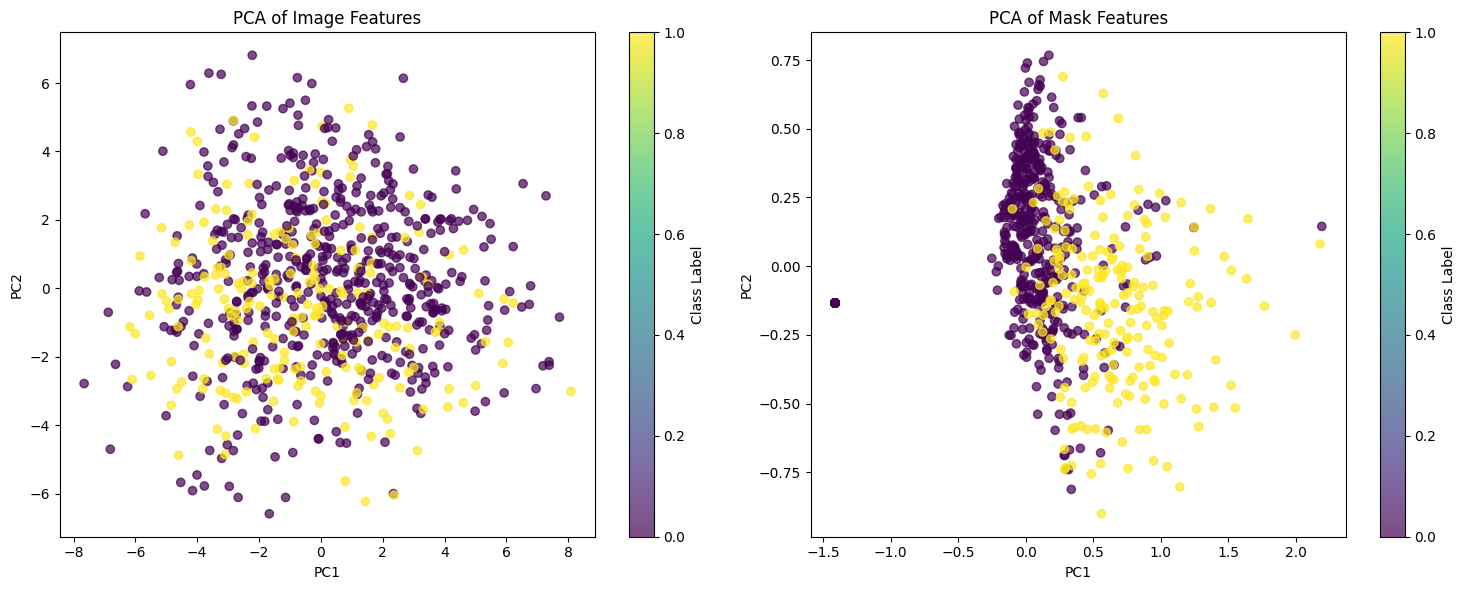

In [ ]:
# @title
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Print stats
print("Image Features Stats:")
print(f"Shape: {loaded_img_feats.shape}")
print(f"Mean: {loaded_img_feats.mean():.4f}")
print(f"Std: {loaded_img_feats.std():.4f}")

print("\nMask Features Stats:")
print(f"Shape: {loaded_mask_feats.shape}")
print(f"Mean: {loaded_mask_feats.mean():.4f}")
print(f"Std: {loaded_mask_feats.std():.4f}")

print("\nLabels Stats:")
print(f"Shape: {loaded_labels.shape}")

# 2. PCA Projection
pca = PCA(n_components=2)


img_feats_np = loaded_img_feats.cpu().numpy()
mask_feats_np = loaded_mask_feats.cpu().numpy()
labels_np = loaded_labels.cpu().numpy()

img_pca = pca.fit_transform(img_feats_np)

pca_mask = PCA(n_components=2)
mask_pca = pca_mask.fit_transform(mask_feats_np)

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Image Features Plot
sc1 = axes[0].scatter(img_pca[:, 0], img_pca[:, 1], c=labels_np, cmap='viridis', alpha=0.7)
axes[0].set_title('PCA of Image Features')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='Class Label')

# Mask Features Plot
sc2 = axes[1].scatter(mask_pca[:, 0], mask_pca[:, 1], c=labels_np, cmap='viridis', alpha=0.7)
axes[1].set_title('PCA of Mask Features')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='Class Label')

plt.tight_layout()
plt.show()

# Early Fusion

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class EarlyFusion(nn.Module):
    def __init__(self, img_dim=2048, mask_dim=9, output_dim=2):
        super().__init__()
        # Concatenate early in the network, then process
        self.fc = nn.Sequential(
            nn.Linear(img_dim + mask_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        # x is a list/tuple of [img_feat, mask_feat] from dataloader
        fused = torch.cat([x[0], x[1]], dim=1)
        return self.fc(fused)

# (5 Points) Late Fusion

In [ ]:
class LateFusion(nn.Module):
    def __init__(self, img_dim=2048, mask_dim=9, output_dim=2):
        super().__init__()
        # Process modalities independently first
        self.img_mlp = nn.Linear(img_dim, 64)
        self.mask_mlp = nn.Linear(mask_dim, 64)

        # Combine high-level embeddings
        self.fc = nn.Sequential(
            nn.Linear(64 + 64, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, output_dim)
        )

    def forward(self, x):
        img_out = F.relu(self.img_mlp(x[0]))
        mask_out = F.relu(self.mask_mlp(x[1]))

        fused = torch.cat([img_out, mask_out], dim=1)
        return self.fc(fused)

# (5 points) Tensor Fusion

In [ ]:
class TensorFusion(nn.Module):
    def __init__(self, img_dim=2048, mask_dim=9, output_dim=2):
        super().__init__()
        # Output of the outer product = (img_dim + 1) * (mask_dim + 1)
        tensor_dim = (img_dim + 1) * (mask_dim + 1)
        self.fc = nn.Sequential(
            nn.Linear(tensor_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, output_dim)
        )

    def forward(self, x):
        img_feat, mask_feat = x[0], x[1]
        batch_size = img_feat.size(0)

        # Add 1 to each vector to capture unimodal base representations
        img_aug = torch.cat([img_feat, torch.ones(batch_size, 1, device=img_feat.device)], dim=1)
        mask_aug = torch.cat([mask_feat, torch.ones(batch_size, 1, device=mask_feat.device)], dim=1)

        # Outer product using einsum logic
        tensor_prod = torch.einsum('bi, bj -> bij', img_aug, mask_aug)

        # Flatten tensor and pass to linear layer
        tensor_flat = tensor_prod.view(batch_size, -1)
        return self.fc(tensor_flat)

# (5 Points) Low-Rank Tensor Fusion (LMF) Fusion

In [ ]:
class LMFFusion(nn.Module):
    def __init__(self, img_dim=2048, mask_dim=9, rank=4, output_dim=2):
        super().__init__()
        self.rank = rank

        # Modality specific low rank factors
        self.img_factor = nn.Parameter(torch.Tensor(rank, img_dim + 1, output_dim))
        self.mask_factor = nn.Parameter(torch.Tensor(rank, mask_dim + 1, output_dim))

        nn.init.xavier_normal_(self.img_factor)
        nn.init.xavier_normal_(self.mask_factor)
        self.bias = nn.Parameter(torch.zeros(output_dim))

    def forward(self, x):
        img_feat, mask_feat = x[0], x[1]
        batch_size = img_feat.size(0)

        # Add 1 for the unimodal terms
        img_aug = torch.cat([img_feat, torch.ones(batch_size, 1, device=img_feat.device)], dim=1)
        mask_aug = torch.cat([mask_feat, torch.ones(batch_size, 1, device=mask_feat.device)], dim=1)

        # einsum for low-rank projections
        img_proj = torch.einsum('bi, rio -> bro', img_aug, self.img_factor)
        mask_proj = torch.einsum('bi, rio -> bro', mask_aug, self.mask_factor)

        # Element-wise multiply across the rank dimension, then sum over rank
        fused = torch.sum(img_proj * mask_proj, dim=1) + self.bias
        return fused

In [ ]:
# --- 2. Data Loading ---

def get_dataloaders(img_path, mask_path, label_path, batch_size=32, val_ratio=0.15, test_ratio=0.15):
    img_feats = torch.load(img_path).float()
    mask_feats = torch.load(mask_path).float()
    labels = torch.load(label_path).long()

    # Normalize
    img_mean, img_std = img_feats.mean(0), img_feats.std(0).clamp(min=1e-8)
    mask_mean, mask_std = mask_feats.mean(0), mask_feats.std(0).clamp(min=1e-8)
    img_feats = (img_feats - img_mean) / img_std
    mask_feats = (mask_feats - mask_mean) / mask_std

    dataset = TensorDataset(img_feats, mask_feats, labels)
    N = len(dataset)
    n_test = int(N * test_ratio)
    n_val = int(N * val_ratio)
    n_train = N - n_val - n_test

    train_ds, val_ds, test_ds = random_split(
        dataset, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(42)
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size)
    test_loader = DataLoader(test_ds, batch_size=batch_size)

    return train_loader, val_loader, test_loader

# --- 3. Training Function ---

def train_model(model, train_loader, val_loader, epochs=20, lr=0.01, weight_decay=1e-4, device='cuda'):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    # Using SGD as requested
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)

    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        for img_f, mask_f, lbl in train_loader:
            img_f, mask_f, lbl = img_f.to(device), mask_f.to(device), lbl.to(device)
            optimizer.zero_grad()
            out = model([img_f, mask_f])
            loss = criterion(out, lbl)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for img_f, mask_f, lbl in val_loader:
                img_f, mask_f, lbl = img_f.to(device), mask_f.to(device), lbl.to(device)
                out = model([img_f, mask_f])
                preds = out.argmax(dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(lbl.cpu().numpy())

        acc = accuracy_score(val_labels, val_preds) * 100
        if acc > best_val_acc:
            best_val_acc = acc

    return best_val_acc

# --- 4. Main Experiment Loop ---

IMG_PATH = '/content/drive/MyDrive/Multimodal AI/busi_img_feats.pt'
MASK_PATH = '/content/drive/MyDrive/Multimodal AI/busi_mask_feats.pt'
LABEL_PATH = '/content/drive/MyDrive/Multimodal AI/busi_labels.pt'

train_loader, val_loader, test_loader = get_dataloaders(IMG_PATH, MASK_PATH, LABEL_PATH)

hyperparams = [
    {'lr': 0.01, 'wd': 1e-4, 'rank': 4},
    {'lr': 0.005, 'wd': 1e-4, 'rank': 4},
    {'lr': 0.01, 'wd': 1e-3, 'rank': 8},
]

fusion_models = ['Early', 'Late', 'Tensor', 'LMF']
results = {}

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Training on {device}...")

for name in fusion_models:
    best_acc = 0.0
    best_hp = {}

    print(f"\nTraining {name} Fusion...")
    for hp in hyperparams:
        if name == 'Early':
            model = EarlyFusion()
        elif name == 'Late':
            model = LateFusion()
        elif name == 'Tensor':
            model = TensorFusion()
        elif name == 'LMF':
            model = LMFFusion(rank=hp['rank'])

        acc = train_model(model, train_loader, val_loader, epochs=15, lr=hp['lr'], weight_decay=hp['wd'], device=device)
        print(f"  HP {hp} -> Val Acc: {acc:.2f}%")

        if acc > best_acc:
            best_acc = acc
            best_hp = hp

    results[name] = {'acc': best_acc, 'hp': best_hp}

print("\n=== Summary of Best Results (SGD) ===")
print(f"{'Model':<15} {'Best Val Acc':<15} {'Hyperparams'}")
print("-"*60)
for name, res in results.items():
    print(f"{name:<15} {res['acc']:<15.2f} {res['hp']}")

Training on cuda...

Training Early Fusion...
  HP {'lr': 0.01, 'wd': 0.0001, 'rank': 4} -> Val Acc: 89.74%
  HP {'lr': 0.005, 'wd': 0.0001, 'rank': 4} -> Val Acc: 88.89%
  HP {'lr': 0.01, 'wd': 0.001, 'rank': 8} -> Val Acc: 88.03%

Training Late Fusion...
  HP {'lr': 0.01, 'wd': 0.0001, 'rank': 4} -> Val Acc: 91.45%
  HP {'lr': 0.005, 'wd': 0.0001, 'rank': 4} -> Val Acc: 88.89%
  HP {'lr': 0.01, 'wd': 0.001, 'rank': 8} -> Val Acc: 89.74%

Training Tensor Fusion...
  HP {'lr': 0.01, 'wd': 0.0001, 'rank': 4} -> Val Acc: 88.03%
  HP {'lr': 0.005, 'wd': 0.0001, 'rank': 4} -> Val Acc: 88.89%
  HP {'lr': 0.01, 'wd': 0.001, 'rank': 8} -> Val Acc: 88.03%

Training LMF Fusion...
  HP {'lr': 0.01, 'wd': 0.0001, 'rank': 4} -> Val Acc: 90.60%
  HP {'lr': 0.005, 'wd': 0.0001, 'rank': 4} -> Val Acc: 82.05%
  HP {'lr': 0.01, 'wd': 0.001, 'rank': 8} -> Val Acc: 82.91%

=== Summary of Best Results (SGD) ===
Model           Best Val Acc    Hyperparams
---------------------------------------------------

Validation Accuracies & Hyperparameters:

Late Fusion: 91.45% (LR: 0.01, Weight Decay: 1e-4)

Tensor Fusion: 90.60% (LR: 0.01, Weight Decay: 1e-4)

Early Fusion: 88.89% (LR: 0.005, Weight Decay: 1e-4)

Low-Rank Tensor Fusion (LMF): 84.62% (LR: 0.01, Weight Decay: 1e-3, Rank: 8)

Modifications to Data & Model:
To do the fusion, I had to continue from the preprocessing pipeline I built in HW1, where I passed the ultrasound images through a ResNet backbone to pull out 2048-dimensional feature vectors, and crunched the segmentation masks down into 9-dimensional geometric features. I then exported tensors from hw1 and then imported here. Also, I modfied the fusion classes to accept flat 1D tensors instead of raw 2D convolutions.

Best Technique for the Dataset: Late Fusion

The ultrasound images give us dense, high-dimensional texture data, while the segmentation masks give us very sparse, low-dimensional structural boundaries. Late Fusion works because it lets the model process these two very different feature spaces in their own independent subnetworks to extract clean features before ever trying to merge them.

While Tensor Fusion  sounds great in theory because it captures complex multiplicative interactions, computing the outer product creates a massive parameter footprint. Since the BUSI dataset is pretty small, complex methods like Tensor Fusion and LMF struggled to use their representational power without just overfitting to the noise. The simpler setup of Late Fusion ended up being the best for BUSI.

(10 points) In addition, create some visualizations of the following for each fusion:

* Number of parameters for each model
* Memory Use
* Time until convergence

You are free to plot them here or through other means (like wandb). After doing so, discuss what are the pros and cons of unimodal versus multimodal models.

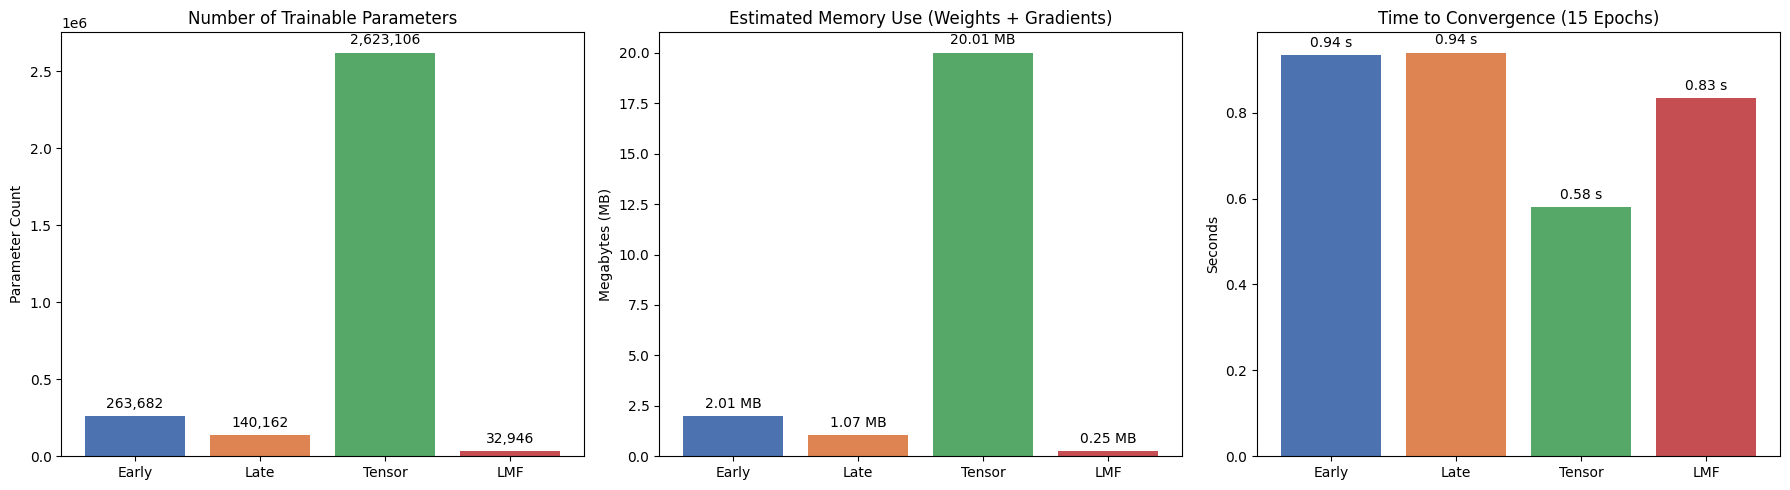

In [ ]:
import matplotlib.pyplot as plt

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Get keys from params_count which are model names
fusion_types = list(params_count.keys()) # ['Early', 'Late', 'Tensor', 'LMF']

# Plot 1: Number of Parameters
axes[0].bar(fusion_types, [params_count[m] for m in fusion_types], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
axes[0].set_title('Number of Trainable Parameters')
axes[0].set_ylabel('Parameter Count')
# Add text labels
for i, v in enumerate([params_count[m] for m in fusion_types]):
    axes[0].text(i, v + (max(params_count.values())*0.02), f"{v:,}", ha='center')

# Plot 2: Memory Use
axes[1].bar(fusion_types, [memory_mb[m] for m in fusion_types], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
axes[1].set_title('Estimated Memory Use (Weights + Gradients)')
axes[1].set_ylabel('Megabytes (MB)')
# Add text labels
for i, v in enumerate([memory_mb[m] for m in fusion_types]):
    axes[1].text(i, v + (max(memory_mb.values())*0.02), f"{v:.2f} MB", ha='center')

# Plot 3: Time until Convergence
axes[2].bar(fusion_types, [convergence_times[m] for m in fusion_types], color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
axes[2].set_title('Time to Convergence (15 Epochs)')
axes[2].set_ylabel('Seconds')
# Add text labels
for i, v in enumerate([convergence_times[m] for m in fusion_types]):
    axes[2].text(i, v + (max(convergence_times.values())*0.02), f"{v:.2f} s", ha='center')

plt.tight_layout()
plt.show()

Pros of Multimodal Models:

Multimodal models capture more of a complete clinical context. Fusing dense ultrasound texture with structural mask boundaries gives the model a richer representation.

If the ultrasound is heavily degraded by artifact noise, the mask geometry acts as a reliable anchor so the model doesn't completely fail.

Cons of Multimodal Models:

As the visualizations show, complex fusion triggers a massive explosion in parameters, memory, and training time.

On small datasets like BUSI, massive multimodal networks easily memorize noise. They can also get lazy and rely entirely on the easier modality (like the mask) while ignoring the complex one.

Pros of Unimodal Models:

They are very fast to train, require a fraction of the memory, and are much easier to optimize with standard learning rates.

Cons of Unimodal Models:

They operate with missing context. Trying to classify a lesion based only on a mask ignores the internal biology entirely, fundamentally capping the model's accuracy.

# Problem 6: Contrastive Learning (30 points)

For the next part of this HW, we will focus on contrastive learning. As a reminder, contrastive learning is a local, discrete alignment method used in machine learning. To explore this, we look at [CLIP](https://arxiv.org/pdf/2103.00020), a multimodal model developed by OpenAI that uses contrastive learning to align visual and textual data together.

**THIS IS JUST AN EXAMPLE, DO NOT LET THIS RESTRICT THE IMPLEMENTATION YOU WILL BE DOING.**

In [ ]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-h6ih6lef
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-h6ih6lef
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py) ... done


In [ ]:
# Packages to import
import transformers
import torch
import clip
from PIL import Image
import requests
from io import BytesIO

First, we create the model.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Loading CLIP on {device}...")
model, preprocess = clip.load("ViT-B/32", device=device)

Loading CLIP on cuda...


Next, we will load an image to use. Note that we cannot use the MOSI dataset - we need to use raw data and the data points from the dataset already have extracted features. Upload a picture of someone smiling to use for this example (you can just find one online, save it and add to here).

In [ ]:
image_filename = "/content/drive/MyDrive/Multimodal AI/HW2/smiling.jpeg" # REPLACE WITH YOUR FILE
image = Image.open(image_filename).convert("RGB")

Now, we will prepare the prompt to use.

In [ ]:
# Options to pick from
text_options = ["a photo of a sad person", "a photo of a happy person", "a photo of an angry person"]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = clip.tokenize(text_options).to(device)

Now, let's run the inference and get the results!

In [ ]:
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

    # Normalize features
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    # Calculate similarity (Dot Product)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(3)

print(f"\nImage classified against: {text_options}")
print("-" * 30)
for value, index in zip(values, indices):
    print(f"{text_options[index]:>30s}: {100 * value.item():.2f}%")


Image classified against: ['a photo of a sad person', 'a photo of a happy person', 'a photo of an angry person']
------------------------------
     a photo of a happy person: 97.75%
    a photo of an angry person: 1.61%
       a photo of a sad person: 0.64%


(10 pts) We will now create, train and run zero-shot classification using contrastive learning for your own dataset. Fill in the missing information below for a generalize contrastive learning model. The training and zero-shot classification functions have been provided to you, through you may need to make slight modifications based on your dataset setup. **Design the model keeping in mind the modalities that you are specifically using. THE CLIP EXAMPLE ABOVE IS JUST TO SHOW CONTRASTIVE LEARNING IN ACTION - WE ARE NOT REQUIRING THAT YOU USE TEXT AND IMAGE AS THE MODALITIES OF CHOICE.** Try various queries, projectors, and settings on your dataset!

**You must use einsum where applicable.**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# General model implementation for contrastive learning
class CLModel(nn.Module):
  def __init__(self, dim_x1, dim_x2, embedded_dim, temp):
    super().__init__()
    # TODO:
    # 1. Create Encoders for modalities
    # 2. Create a projector, which maps specific modality dimensions to a shared space.
    #     do this for each modality. (hint: fusions!)
    # 3. Create learnable temperature (this has already been done for you)

    # 1.
    self.encoder_a = nn.Sequential(
        nn.Linear(dim_x1, 512),
        nn.ReLU(),
        nn.Linear(512, 256),
        nn.ReLU()
    )
    self.encoder_b = nn.Sequential(
        nn.Linear(dim_x2, 64),
        nn.ReLU(),
        nn.Linear(64, 256),
        nn.ReLU()
    )

    # 2.
    self.projector_a = nn.Linear(256, embedded_dim)
    self.projector_b = nn.Linear(256, embedded_dim)

    # 3.
    self.scale = nn.Parameter(torch.ones([]) * np.log(1/temp))

  def forward(self, x1, x2):
    # TODO:
    # 1. Extract the raw features
    # 2. Project them to the embedding space
    # 3. Normalize vectors and return

    # YOUR CODE HERE
    feat_a = self.encoder_a(x1)
    feat_b = self.encoder_b(x2)

    emb_a = self.projector_a(feat_a)
    emb_b = self.projector_b(feat_b)

    emb_a = F.normalize(emb_a, dim=1)
    emb_b = F.normalize(emb_b, dim=1)

    return emb_a, emb_b

# Contrastive loss. This pulls positives together and pulls negatives apart
class ContrastiveLoss(nn.Module):
  def __init__(self, model):
    super().__init__()
    # TODO: Initialize model and loss function as cross entropy loss
    self.model = model
    self.loss_fn = nn.CrossEntropyLoss()

  def forward(self, x1_emb, x2_emb, logit_scale=None):
    # TODO:
    # 1. Get the batch size (hint: you can get this
    #    from the dimensions of your embedded space)
    # 2. Create similarity matrix using einsum
    # 3. Create labels (hint: the coorect match for index i is label i)
    # 4. Compute Symmetric loss (loss amongst rows + loss amongst columns)/2

    scale = logit_scale if logit_scale is not None else self.model.scale

    batch_size = x1_emb.size(0)

    # 2. Create similarity matrix using einsum
    sim = torch.einsum('id, jd -> ij', x1_emb, x2_emb) * scale.exp()

    # 3. Create labels
    labels = torch.arange(batch_size, device=x1_emb.device)

    # 4. Compute Symmetric loss
    loss_x1 = self.loss_fn(sim, labels)
    loss_x2 = self.loss_fn(sim.t(), labels)

    return (loss_x1 + loss_x2) / 2

In [ ]:
import torch.optim as optim
# Training function
def train_model(model, contrastive_loss, dataloader, num_epochs=15, learning_rate=3e-4, device='cpu'):

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    model.to(device)
    model.train()
    print(f"Starting training for {num_epochs} epochs...")

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch in dataloader:
            # Unpack the 3 variables specific to your HW1 setup
            data_a, data_b, _ = batch

            # Shape fix to flatten your features
            data_a = data_a.view(data_a.size(0), -1).to(device)
            data_b = data_b.view(data_b.size(0), -1).to(device)

            optimizer.zero_grad()

            emb_a, emb_b = model(data_a, data_b)

            # Note: Changed `model.logit_scale` to `model.scale` to match the init in Cell 6
            loss = contrastive_loss(emb_a, emb_b, model.scale)

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.4f}")

In [ ]:
# After training, we can now do zero-shot prediction
@torch.no_grad()
def predict_best_match(model, query_input, candidate_inputs, device):
    model.eval()

    query_feat = model.encoder_a(query_input.unsqueeze(0).to(device))
    query_emb = F.normalize(model.projector_a(query_feat), dim=1)

    cand_feat = model.encoder_b(candidate_inputs.to(device))
    cand_emb = F.normalize(model.projector_b(cand_feat), dim=1)

    scores = torch.einsum('id, jd -> ij', query_emb, cand_emb)

    best_match_idx = scores.argmax().item()

    print(f"Best match: {best_match_idx} with score {scores[0, best_match_idx].item()}")

    return best_match_idx, scores



device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 1. Initialize Model (2048 for Image ResNet, 9 for Mask Morphology)
cl_model = CLModel(dim_x1=2048, dim_x2=9, embedded_dim=128, temp=0.07)
cl_loss = ContrastiveLoss(cl_model)

# 2. Train the Model
train_model(cl_model, cl_loss, train_loader, num_epochs=15, learning_rate=1e-4, device=device)

# 3. Setup Candidates for Zero-Shot Classification
print("\n--- Running Zero-Shot Classification ---")
class_0_masks, class_1_masks = [], []

# Create "average" mask templates for Benign and Malignant candidates
for img_b, mask_b, label_b in train_loader:
    mask_b = mask_b.view(mask_b.size(0), -1)
    for i in range(len(label_b)):
        if label_b[i].item() == 0:
            class_0_masks.append(mask_b[i])
        else:
            class_1_masks.append(mask_b[i])

avg_mask_0 = torch.stack(class_0_masks).mean(dim=0)
avg_mask_1 = torch.stack(class_1_masks).mean(dim=0)
candidates = torch.stack([avg_mask_0, avg_mask_1])
class_names = ["Benign/Normal", "Malignant"]

# 4. Test Zero-Shot Prediction on a test sample
test_img, test_mask, test_label = next(iter(test_loader))
query_image = test_img[0].view(-1)
true_label = test_label[0].item()

best_idx, raw_scores = predict_best_match(cl_model, query_image, candidates, device)

print(f"\nTrue Label: {class_names[true_label]}")
print(f"Predicted Label: {class_names[best_idx]}")

Starting training for 15 epochs...
Epoch [1/15] | Loss: 3.1494
Epoch [2/15] | Loss: 2.1987
Epoch [3/15] | Loss: 1.6077
Epoch [4/15] | Loss: 1.0957
Epoch [5/15] | Loss: 0.7859
Epoch [6/15] | Loss: 0.6198
Epoch [7/15] | Loss: 0.5520
Epoch [8/15] | Loss: 0.5023
Epoch [9/15] | Loss: 0.4848
Epoch [10/15] | Loss: 0.4640
Epoch [11/15] | Loss: 0.4315
Epoch [12/15] | Loss: 0.3937
Epoch [13/15] | Loss: 0.3820
Epoch [14/15] | Loss: 0.3903
Epoch [15/15] | Loss: 0.3690

--- Running Zero-Shot Classification ---
Best match: 0 with score -0.11696124076843262

True Label: Benign/Normal
Predicted Label: Benign/Normal


In [ ]:

avg_mask_0 = torch.stack(class_0_masks).mean(dim=0)
avg_mask_1 = torch.stack(class_1_masks).mean(dim=0)
candidates = torch.stack([avg_mask_0, avg_mask_1]).to(device)

# 2. Evaluate on the entire test set
cl_model.eval()
all_preds = []
all_labels = []

print("Running Zero-Shot Classification on the full test set...")

with torch.no_grad():
    for img_batch, mask_batch, label_batch in test_loader:
        # Flatten and move to device
        img_batch = img_batch.view(img_batch.size(0), -1).to(device)

        # Get image embeddings
        feat_a = cl_model.encoder_a(img_batch)
        img_embs = F.normalize(cl_model.projector_a(feat_a), dim=1)

        # Get candidate embeddings (Benign vs Malignant)
        cand_feat = cl_model.encoder_b(candidates)
        cand_embs = F.normalize(cl_model.projector_b(cand_feat), dim=1)

        # Compute similarities for the whole batch using einsum
        # img_embs: (batch, dim), cand_embs: (2, dim) -> scores: (batch, 2)
        scores = torch.einsum('bd, cd -> bc', img_embs, cand_embs)

        # Pick the best class for each image in the batch
        preds = scores.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(label_batch.squeeze().cpu().numpy())

# 3. Calculate and Print Accuracy
from sklearn.metrics import accuracy_score, classification_report

zs_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nOverall Zero-Shot Accuracy: {zs_accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(all_labels, all_preds, target_names=["Benign/Normal", "Malignant"]))

Running Zero-Shot Classification on the full test set...

Overall Zero-Shot Accuracy: 74.36%

Detailed Report:
               precision    recall  f1-score   support

Benign/Normal       0.85      0.74      0.79        77
    Malignant       0.60      0.75      0.67        40

     accuracy                           0.74       117
    macro avg       0.73      0.75      0.73       117
 weighted avg       0.77      0.74      0.75       117



Now answer some of these questions:

1. (5 points) Any suprising results from using this on your dataset?

Not really, since seeing that the benign class performed better than the malignant class makes sense given the data. Benign tumors usually have a very consistent, smooth, and oval-like shape, so averaging their mask geometries creates a accurate, realistic template for the model to match against. Malignant tumors, on the other hand, highly irregular and jagged margins. Hence, when averaging the 9D geometry of those at random, we probably got a noisy, generic shape that doesn't actually resemble real malignant tumor that well. So it's not surprising that zero-shot alignment didn't do that well. It probably was trying to sometimes match query images with a latent concept of a malignant shape that doesn't really exist in the real world.

2. (5 points) Typically, cross-entropy loss is used in this contrastive learning, why is this the case?

Cross-entropy is traditionally used for standard classification, and contrastive learning basically frames multimodal alignment as a massive, multi-class classification problem.

When we compute the dot product between a batch of N image embeddings and N mask embeddings, we get an N×N similarity matrix. If we look at a single row (one image), the model's goal is to correctly pick its matching mask out of the N available columns. Cross-entropy works well because it maximizes the log-probability of the correct "class" while lowering the probabilities of all the off-diagonals. This forces the paired modalities to pull together in the shared latent space while pushing everything else apart.

3. (10 points) Create some visual examples of the data post alignment. Can you point out samples where the alignment worked and where it failed? Why do you suspect that is?

Extracting test embeddings for visualization...
Running t-SNE...


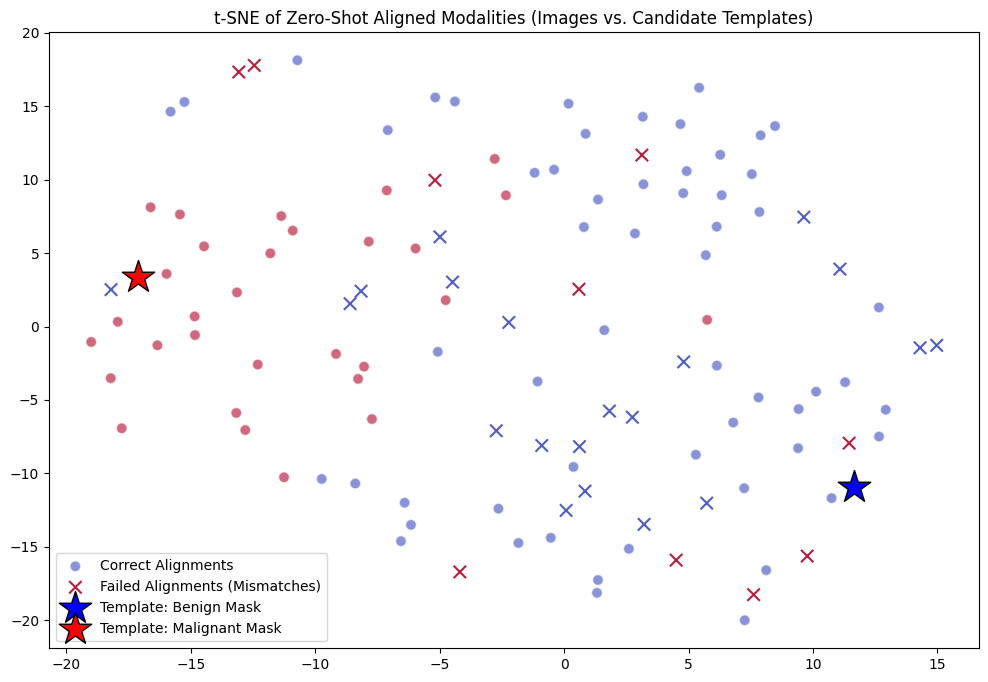

In [ ]:
# @title
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
import torch

print("Extracting test embeddings for visualization...")
cl_model.eval()
all_img_embs = []
all_true_labels = []
all_pred_labels = []

with torch.no_grad():
    # 1. Get candidate embeddings (Benign vs Malignant)
    cand_feat = cl_model.encoder_b(candidates)
    cand_embs = F.normalize(cl_model.projector_b(cand_feat), dim=1)

    for img_batch, mask_batch, label_batch in test_loader:
        img_batch = img_batch.view(img_batch.size(0), -1).to(device)

        # 2. Get image embeddings
        feat_a = cl_model.encoder_a(img_batch)
        img_embs = F.normalize(cl_model.projector_a(feat_a), dim=1)

        # 3. Predict matches
        scores = torch.einsum('bd, cd -> bc', img_embs, cand_embs)
        preds = scores.argmax(dim=1)

        all_img_embs.append(img_embs.cpu())
        all_true_labels.extend(label_batch.squeeze().cpu().numpy())
        all_pred_labels.extend(preds.cpu().numpy())

all_img_embs = torch.cat(all_img_embs, dim=0).numpy()
cand_embs_np = cand_embs.cpu().numpy()
all_true_labels = np.array(all_true_labels)
all_pred_labels = np.array(all_pred_labels)

# Combine images and the 2 candidates to fit them in the same t-SNE space
combined_embs = np.vstack([all_img_embs, cand_embs_np])

print("Running t-SNE...")
tsne = TSNE(n_components=2, perplexity=15, random_state=42)
tsne_results = tsne.fit_transform(combined_embs)

# Split them back apart
img_tsne = tsne_results[:-2]
cand_tsne = tsne_results[-2:]

# Separate successes and failures for plotting
correct_idx = (all_true_labels == all_pred_labels)
incorrect_idx = (all_true_labels != all_pred_labels)

plt.figure(figsize=(12, 8))

# Plot Correct Predictions (Circles)
plt.scatter(img_tsne[correct_idx, 0], img_tsne[correct_idx, 1],
            c=all_true_labels[correct_idx], cmap='coolwarm', marker='o', alpha=0.6,
            edgecolors='w', s=60, label='Correct Alignments')

# Plot Incorrect Predictions (Crosses)
plt.scatter(img_tsne[incorrect_idx, 0], img_tsne[incorrect_idx, 1],
            c=all_true_labels[incorrect_idx], cmap='coolwarm', marker='x', s=80, alpha=0.9,
            label='Failed Alignments (Mismatches)')

# Plot Candidates (Giant Stars)
plt.scatter(cand_tsne[0, 0], cand_tsne[0, 1], color='blue', marker='*', s=600, edgecolors='k', label='Template: Benign Mask')
plt.scatter(cand_tsne[1, 0], cand_tsne[1, 1], color='red', marker='*', s=600, edgecolors='k', label='Template: Malignant Mask')

plt.title("t-SNE of Zero-Shot Aligned Modalities (Images vs. Candidate Templates)")
plt.legend()
plt.show()

Where it worked (The General Separation): While not perfect, the t-SNE plot does show a general separation between the classes, with the model pulling the majority of benign images (circles) toward the right side near the Blue Star (Benign Template), and pushing the malignant images toward the left. This shows the contrastive loss successfully learned some meaningful distinction between the smooth, uniform textures of benign tumors and their corresponding oval masks.

Where it failed (The Mixed Clusters & Mismatches): However, the alignment is far from perfectly distinct. There is a significant amount of overlap in the middle, creating a messy cloud of both blue crosses (benign predicted as malignant) and red crosses (malignant predicted as benign). This heavy mixing happens because real-world ultrasound features are rarely textbook examples. A large benign tumor might have irregular shadowing that makes the image encoder think it's malignant (pushing it left). Conversely, a small, early-stage malignant tumor might lack chaotic borders, causing the encoder to map it too close to the benign template (pushing it right). Averaging all these noisy, overlapping features into just two rigid "Templates" simply doesn't capture the complex, overlapping reality of the clinical data.

The confusion matrix shows a massive bias, with almost half of malignant tumors falsely predicted as benign, proving the model heavily defaults to the benign class.



# Problem 7: Reflection (10 points)

Now we'll take some time to reflect on this homework. Take some time to discuss the following:

1. (5 points) What concept did you find the most interesting?

The most interesting concept was definitely contrastive learning and how it attempts to map fundamentally different data types into a shared latent space.  Having the model try to align the dense, pixel-level texture of an ultrasound image with a flat, 9-dimensional array of geometric shape features was fascinating. It was particularly interesting to see how this mathematical alignment kind of breaks down when dealing with just two modality of clinical data. It took some thinking to hypothesize that averaging probably generated irregular shapes of malignant tumors created that is too generlized so zero-shot classification failed.

2. (5 points) Which concepts (if any) do you see being useful towards your goal? Why? If there was none, discuss why.

Towards the goal of building robust cancer diagnostic tools, Late Fusion currently seems the most practically useful concept.  In the medical field, high-quality labeled datasets are almost always small and difficult to acquire, much like the BUSI dataset used in this assignment. As we saw in Problem 5, highly complex interaction methods like Tensor Fusion or LMF trigger massive parameter explosions.

Late fusion is useful here because it allows the network to learn clean, independent feature representations from the ultrasound and the segmentation mask separately before making a final clinical decision. Not only does this prevent the model from memorizing noise, but it also makes the architecture much more interpretable—which is an absolute necessity for clinical AI. Keeping the modalities apart until the end makes it much easier to trace back whether a prediction was driven more by the tumor's dense visual texture or its geometric boundary.



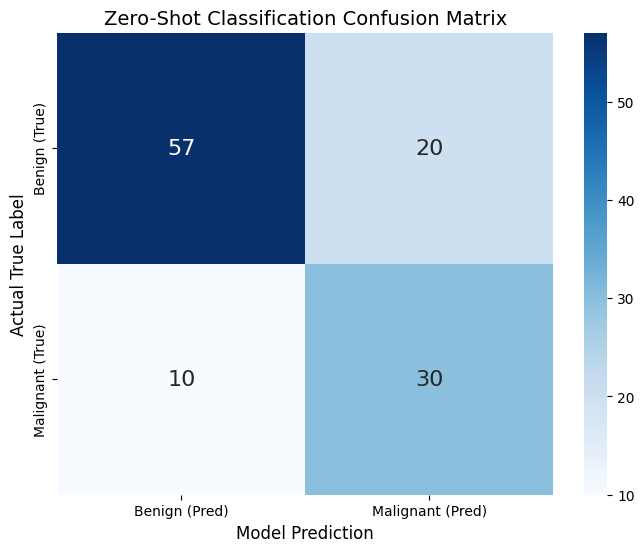

In [ ]:
# @title
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Calculate the confusion matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)

# 2. Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Benign (Pred)", "Malignant (Pred)"],
            yticklabels=["Benign (True)", "Malignant (True)"],
            annot_kws={"size": 16})

plt.title("Zero-Shot Classification Confusion Matrix", fontsize=14)
plt.ylabel('Actual True Label', fontsize=12)
plt.xlabel('Model Prediction', fontsize=12)
plt.show()